# MLP (Multilayer Perceptron)

In [1]:
import os
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)


print("Libraries loaded")
print("Seed fixed:", SEED)

Libraries loaded
Seed fixed: 42


In [2]:
train_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Train_80.csv"
)


test_data = pd.read_csv(
    r"../datasets/CICIDS2017/train_test/CICIDS2017_Test_20.csv"
)


print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (1948553, 41)
Test shape : (487139, 41)


In [3]:
X_train = train_data.drop(
    "label",
    axis=1
).values


X_test = test_data.drop(
    "label",
    axis=1
).values


y_train = train_data["label"].values

y_test = test_data["label"].values


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1948553, 40)
X_test : (487139, 40)
y_train: (1948553,)
y_test : (487139,)


In [4]:
num_classes = len(
    np.unique(y_train)
)


y_train_cat = to_categorical(
    y_train,
    num_classes
)


y_test_cat = to_categorical(
    y_test,
    num_classes
)


print("Classes:", num_classes)

print(
    y_train_cat.shape
)

print(
    y_test_cat.shape
)

Classes: 14
(1948553, 14)
(487139, 14)


In [5]:
class_weights = compute_class_weight(

    class_weight="balanced",

    classes=np.unique(y_train),

    y=y_train

)


class_weight_dict = {
    i: class_weights[i]
    for i in range(num_classes)
}


print(class_weight_dict)

{0: np.float64(0.09742706543760737), 1: np.float64(31.589277608456), 2: np.float64(1.8173342013273595), 3: np.float64(20.801428357922155), 4: np.float64(0.500809086025789), 5: np.float64(25.36121668054977), 6: np.float64(33.602693660757396), 7: np.float64(18.25342388758782), 8: np.float64(13918.235714285714), 9: np.float64(1.07844811745771), 10: np.float64(29.246135142436888), 11: np.float64(63.64076686916193), 12: np.float64(7325.387218045113), 13: np.float64(128.04264686555396)}


In [6]:
mlp_model = Sequential([


    Dense(
        256,
        activation="relu",
        input_shape=(40,)
    ),

    BatchNormalization(),

    Dropout(0.3),


    Dense(
        128,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.3),


    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.2),


    Dense(
        num_classes,
        activation="softmax"
    )

])


mlp_model.summary()

c:\Users\farda\anaconda3\envs\myenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,094 (211.30 KB)

 Trainable params: 53,326 (208.30 KB)

 Non-trainable params: 768 (3.00 KB)

In [7]:
mlp_model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)


print("Model compiled")

Model compiled


In [8]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)


reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1

)

In [9]:
history = mlp_model.fit(

    X_train,

    y_train_cat,

    validation_split=0.2,

    epochs=30,

    batch_size=1024,

    class_weight=class_weight_dict,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1

)


Epoch 1/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.6325 - loss: 1.9133 - val_accuracy: 0.6238 - val_loss: 1.2199 - learning_rate: 0.0010
Epoch 2/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.6414 - loss: 1.5286 - val_accuracy: 0.5807 - val_loss: 1.1770 - learning_rate: 0.0010
Epoch 3/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.6426 - loss: 1.6886 - val_accuracy: 0.5766 - val_loss: 1.3710 - learning_rate: 0.0010
Epoch 4/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.6373 - loss: 0.9864 - val_accuracy: 0.6186 - val_loss: 1.1732 - learning_rate: 0.0010
Epoch 5/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.6620 - loss: 1.4981 - val_accuracy: 0.5950 - val_loss: 1.4033 - learning_rate: 0.0010
Epoch 6/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.6573 - loss: 0.9766 - val_accuracy: 0.6027 - val_loss: 1.0605 - learning_rate: 0.0010
Epoch 7/30
1523/1523 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accura

In [10]:
y_prob = mlp_model.predict(

    X_test,

    verbose=1

)


y_pred = np.argmax(

    y_prob,

    axis=1

)




15224/15224 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step


In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.850849552181205
Precision: 0.9486751352547287
Recall   : 0.850849552181205
F1 Score : 0.88594315833038


In [12]:
print(

    classification_report(

        y_test,

        y_pred,

        digits=4

    )

)

              precision    recall  f1-score   support

           0     0.9994    0.8027    0.8903    357145
           1     0.1803    1.0000    0.3055      1102
           2     0.9742    0.9990    0.9864     19147
           3     0.3278    0.8679    0.4759      1673
           4     0.7561    0.9904    0.8575     69479
           5     0.1759    0.8805    0.2932      1372
           6     0.3722    0.7005    0.4861      1035
           7     0.3484    0.9906    0.5155      1906
           8     0.0000    0.0000    0.0000         2
           9     0.9859    0.9854    0.9857     32265
          10     0.1135    0.9866    0.2036      1190
          11     0.0505    0.6600    0.0939       547
          12     0.0006    1.0000    0.0012         5
          13     0.0252    0.5203    0.0481       271

    accuracy                         0.8508    487139
   macro avg     0.3793    0.8131    0.4388    487139
weighted avg     0.9487    0.8508    0.8859    487139



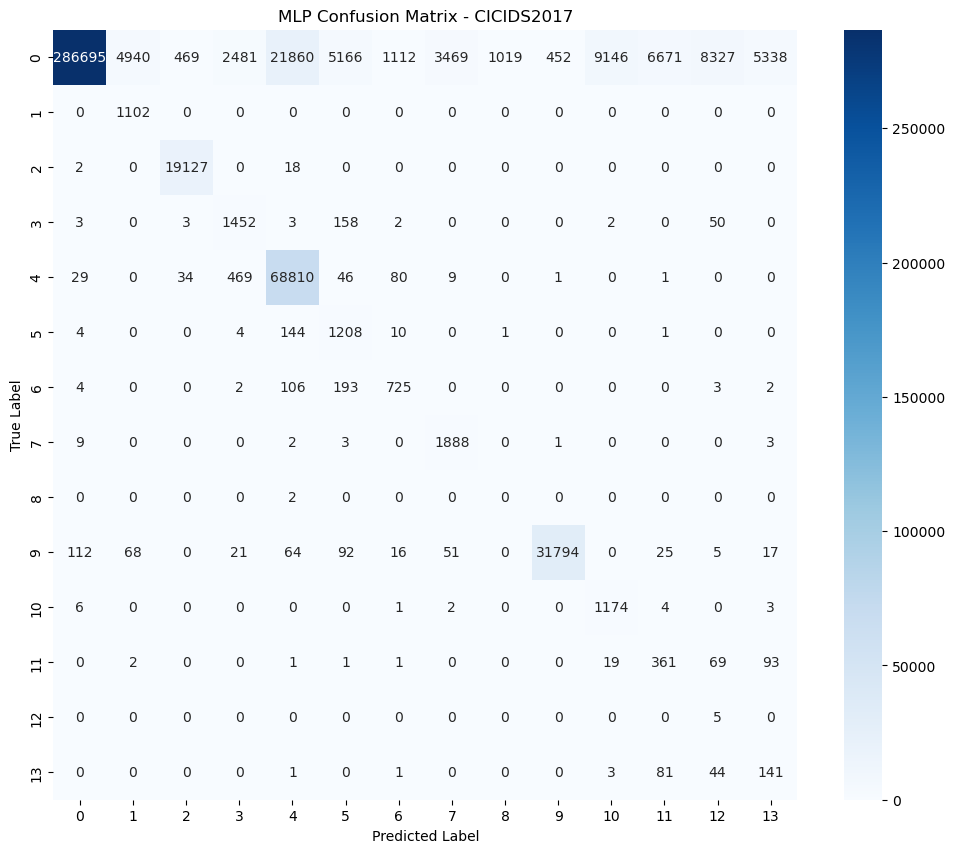

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(
    figsize=(12,10)
)


sns.heatmap(

    cm,

    cmap="Blues",
    annot=True,

    fmt="d"

)


plt.xlabel(
    "Predicted Label"
)


plt.ylabel(
    "True Label"
)


plt.title(
    "MLP Confusion Matrix - CICIDS2017"
)


plt.show()

In [14]:
mlp_model.save(
    "MLP_CICIDS2017.keras"
)


print("MLP model saved")

MLP model saved


In [15]:
mlp_results = pd.DataFrame({

    "Model": [
        "MLP"
    ],

    "Accuracy": [
        accuracy
    ],

    "Precision": [
        precision
    ],

    "Recall": [
        recall
    ],

    "F1_Score": [
        f1
    ],

})


mlp_results.to_csv(
    "MLP_results.csv",
    index=False
)


print(mlp_results)

  Model  Accuracy  Precision   Recall  F1_Score
0   MLP   0.85085   0.948675  0.85085  0.885943


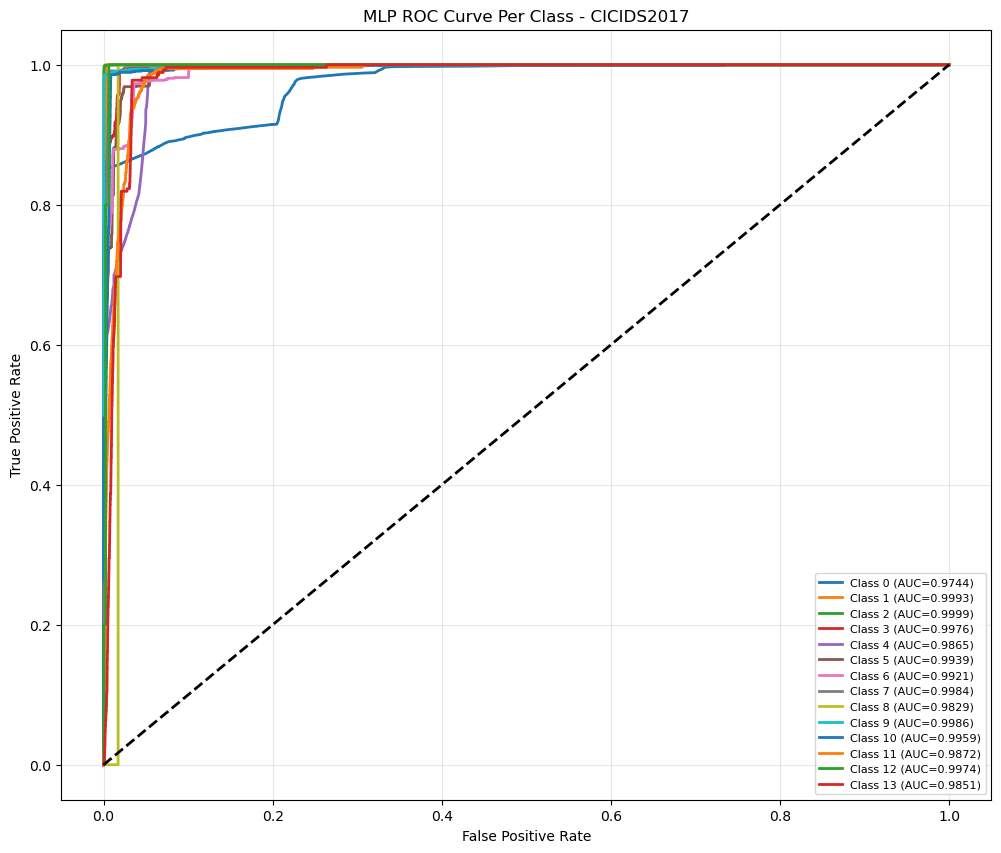

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize test labels
classes = np.unique(y_test)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

num_classes = len(classes)

# Plot ROC per class
plt.figure(figsize=(12, 10))

for i in range(num_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {classes[i]} (AUC={roc_auc:.4f})"
    )

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    linewidth=2
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "MLP ROC Curve Per Class - CICIDS2017"
)

plt.legend(
    loc="lower right",
    fontsize=8
)

plt.grid(alpha=0.3)

plt.show()